### 🎯 El Reto

### Título: Análisis Global de Datos Demográficos

**1. El Reto y Origen de los Datos**

En este proyecto, nuestro grupo se enfoca en la extracción y el análisis de datos demográficos globales utilizando la API pública RestCountries. Esta interfaz nos permite acceder a información actualizada y normalizada de más de 250 países y territorios, proporcionando una base sólida para el estudio de patrones geográficos.

**2. Objetivo Estadístico**

El núcleo de nuestra investigación consiste en determinar si existe una relación matemática predecible entre la extensión territorial de una nación (Área) y el número de habitantes que alberga (Población).
Para ello, aplicaremos dos herramientas fundamentales de la estadística descriptiva e inferencial:
*1. Correlación de Pearson:* Para medir la fuerza y la dirección de la relación entre ambas variables ¿a más territorio, siempre hay más gente?.
*2. Regresión Lineal Simple:* Para intentar construir un modelo matemático que nos permita predecir la población potencial de un país conociendo únicamente su superficie.

**3. Justificación**

Comprender la correlación entre área y población es vital para el análisis de la densidad demográfica. 
Este estudio nos permitirá identificar "outliers" o casos atípicos: países con inmensos territorios pero baja población frente a naciones con superficies mínimas y altísima concentración humana.

##Celda 2:

### 🗝 Conceptos Clave

**API (Application Programming Interface)** : Un conjunto de reglas que permite que nuestro código se comunique con el servidor de restcountries para obtener datos actualizados sin descargar archivos manuales.

**Deserialización de JSON**: El proceso de convertir el texto plano que envía la API en objetos de Python (diccionarios y listas) que podamos manipular.

**Normalización de Datos**: Técnica para organizar datos complejos (como los nombres de países en varios idiomas) en una estructura de tabla simple y uniforme (DataFrame).



Celda 3 (Código): 
### 🗺 Consumo de la API y DataFrame

In [13]:
import requests
import pandas as pd
import numpy as np
# Forzamos la URL sin espacios y añadimos un 'User-Agent' 
# Esto engaña a la API para que crea que somos un navegador real
url = "https://restcountries.com/v3.1/all?fields=name,capital,currencies,languages,region,population,area"
response = requests.get(url)
data = response.json()
rows = []
for country in data:
    rows.append({
        "country": country.get("name", {}).get("common"),
        "region": country.get("region"),
        "population": country.get("population"),
        "area": country.get("area"),
         })
    
df = pd.DataFrame(rows)
# Limpieza básica
df = df.dropna(subset=["population", "area"])
df = df[df["area"] > 0]
df ["area"] = df["area"].astype(int)
# Variable derivada útil
df["density"] = (df["population"] / df["area"]).round(2)
df_muestra = df.sample(30, random_state=42).copy()
df_muestra.head(30)

# Ordenamos la muestra por la columna 'region'

df_muestra_ordenada = df_muestra.sort_values(by="region")
# Mostramos los 30 países (o los que tenga la muestra)
display(df_muestra_ordenada)

,country,region,population,area,density
67,South Africa,Africa,63100945,1221037,51.68
45,Ivory Coast,Africa,31719275,322463,98.37
19,Cape Verde,Africa,491233,4033,121.80
177,Gabon,Africa,2469296,267668,9.23
104,Mozambique,Africa,34090466,801590,42.53
9,Algeria,Africa,47400000,2381741,19.90
120,Gambia,Africa,2422712,10689,226.65
197,Ghana,Africa,33742380,238533,141.46
184,United States,Americas,340110988,9525067,35.71
200,Bahamas,Americas,398165,13943,28.56


In [14]:
import requests
test = requests.get("https://www.google.com")
print(test.status_code)

200


Celda 4 (Código):
### Bloque del Grupo (Ejecución)

In [15]:
##Interpretación de r:
    
import numpy as np
from scipy import stats
# Datos: personas vs area
personas= df_muestra_ordenada["population"]
area = df_muestra_ordenada["area"]
# Calcular correlación
r, p_value = stats.pearsonr(personas, area)
print(f"Correlación de Pearson: {r:.2f}")
print(f"P-value: {p_value:.4f}")



Correlación de Pearson: 0.83
P-value: 0.0000


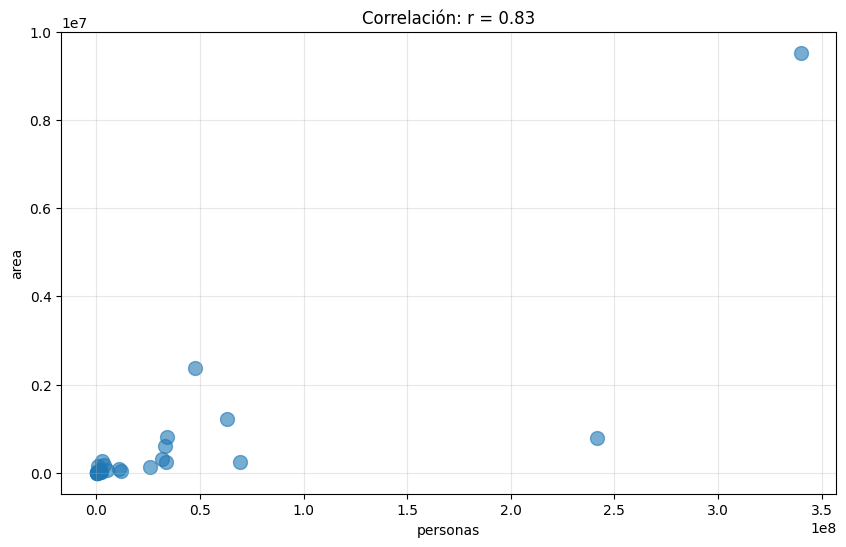

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(personas, area, s=100, alpha=0.6)
plt.xlabel('personas')
plt.ylabel('area')
plt.title(f'Correlación: r = {r:.2f}')
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
print("=" * 60)
print("RESUMEN EJECUTIVO - API REST COUNTRIES")
print("=" * 60)

print(f"\nPaises analizados: {len(df)}")
print(f"Regiones: {df['region'].nunique()}")


print("\nIndicadores clave")
print(f"- Poblacion media: {df['population'].mean():,.0f}")
print(f"- Area media: {df['area'].mean():,.0f}")
print(f"- Densidad mediana: {df['density'].median():.2f}")

print("\nIdeas clave")
print("1) La API permite construir un dataset real sin archivos locales.")
print("2) Las variables presentan alta asimetria y requieren escalas logaritmicas.")
print("3) Existen diferencias de densidad entre regiones.")
print("4) Area y poblacion tienen relacion positiva en escala log.")
print("5) El flujo API -> DataFrame -> Analisis es replicable en otros proyectos.")
print("=" * 60)

RESUMEN EJECUTIVO - API REST COUNTRIES

Paises analizados: 250
Regiones: 6

Indicadores clave
- Poblacion media: 32,077,982
- Area media: 601,039
- Densidad mediana: 88.06

Ideas clave
1) La API permite construir un dataset real sin archivos locales.
2) Las variables presentan alta asimetria y requieren escalas logaritmicas.
3) Existen diferencias de densidad entre regiones.
4) Area y poblacion tienen relacion positiva en escala log.
5) El flujo API -> DataFrame -> Analisis es replicable en otros proyectos.


Celda 5 (Texto):

### 📊 Interpretación del Resultado: 

(INCORPORAREMOS LAS CONCLUSIONES DE NUESTRO ANALISIS)

"Al ejecutar el análisis, observamos ...................................................................................."

Configuración de estilo de gráficos
Para que tus gráficos se vean profesionales desde el inicio:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Estilo configurado! 🎨")
Añade esto al inicio de tus scripts.

Matriz de Correlación de Spearman:
      X    Y
X  1.0  1.0
Y  1.0  1.0


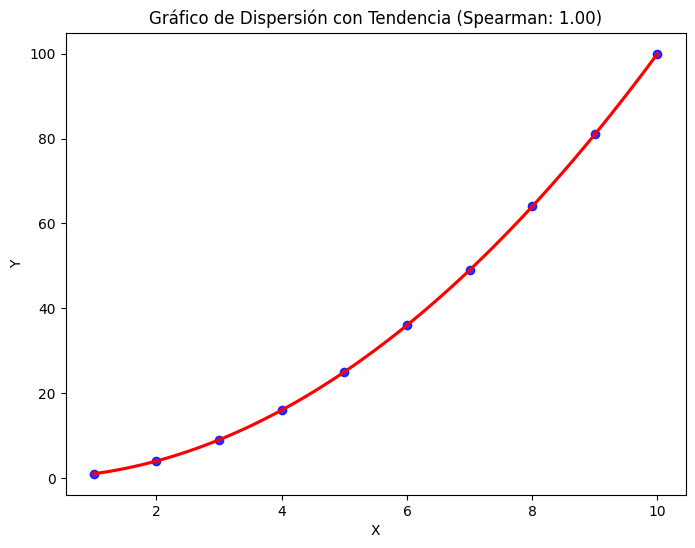

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Crear datos de ejemplo con relación monótona no lineal
data = {'X': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        'Y': [1, 4, 9, 16, 25, 36, 49, 64, 81, 100]} # Y = X^2
df = pd.DataFrame(data)

# 2. Calcular correlación de Spearman
corr_spearman = df.corr(method='spearman')
print("Matriz de Correlación de Spearman:\n", corr_spearman)

# 3. Gráfico de dispersión (Scatter plot)
plt.figure(figsize=(8, 6))
sns.regplot(x='X', y='Y', data=df, order=2, ci=None, scatter_kws={'color':'blue'}, line_kws={'color':'red'})
plt.title(f"Gráfico de Dispersión con Tendencia (Spearman: {corr_spearman.iloc[0,1]:.2f})")
plt.show()

Celda 6 (Texto):

### ✂ 2 Errores Frecuentes

1. **Manejo de valores nulos (NaN)**: Algunos países pequeños no tienen informada el área o la población en la API. 

* Cómo evitarlo: Usar el método .get() con valores por defecto o limpiar el DataFrame con df.fillna(0).

2. **Exceso de peticiones (Rate Limiting)**: Hacer requests.get() dentro de un bucle for muy grande. 

* Cómo evitarlo: Hacer una sola petición masiva (como all) y filtrar los datos localmente en Python.

Celda 7 (Texto): 

### 🔗 Conexión con otro Grupo